# **Why skipping EDA is a bad idea?**

**You can always skip the Exploration Data Analysis stage and go directly to the model building stage, or do a superficial one, this is often found among newcomers to Data Science. Such a careless attitude can lead to data corruption due to the presence of outliers or a large number of missing values in the attribute, and consequently, to sad results for the project as a whole.
Consequences:
     creation of low-quality models;
     building good models on distorted data;
     selection of incorrect features for transfer to the model;
     inefficient use of resources due to the use of low-quality features;
EDA is used, on the one hand, to answer questions, test business assumptions, generate hypotheses and further analysis. On the other hand, we can use the EDA stage to prepare the data for simulation.**

# **Install the required dependencies**

In [1]:
# !pip install missingno

# **Importing the required libraries**

In [2]:
from typing import List, Optional
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns
import scipy.stats as st
from scipy.stats import probplot, ks_2samp

from sklearn.ensemble import RandomForestRegressor
from sklearn.utils.validation import check_is_fitted
import missingno as msno
%matplotlib inline

from pathlib import Path

In [3]:
DATA_ROOT = Path('/kaggle/input/spaceship-titanic')
DF_TRAIN = DATA_ROOT / 'train.csv'
DF_TEST = DATA_ROOT / 'test.csv'

In [4]:
train = pd.read_csv(DF_TRAIN)
test = pd.read_csv(DF_TEST)

print("train.shape = {} rows, {} cols".format(*train.shape))
print("test.shape = {} rows, {} cols".format(*test.shape))

train.shape = 8693 rows, 14 cols
test.shape = 4277 rows, 13 cols


**One of the easiest things we can do with a new dataset is to calculate basic statistics on the dataset. Basic statistics is a fairly broad term: we can interpret it as a quick and rough way to get some information about the data, as a way to get some simple, easy to understand information about the data, to get a basic understanding of the data. We can use the describe method to get summary statistics for all values except for gaps.**

In [5]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


**Once we've got a general idea of the data set, it's worth taking a closer look at the data itself. Using the head(), tail() methods, we can easily look at the beginning and end of the pandas.DataFrame in which the data is concentrated.**

In [6]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# **Numerical features**

In [7]:
numerical_features = train.select_dtypes(include=[np.number])
print(f"count of numeric_features {numerical_features.shape[1]}")

numerical_features.columns

count of numeric_features 6


Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')

In [8]:
numerical_features.head(n=2)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0


**For continuous features, it makes sense to build distribution histograms or distribution functions, as well as the dependence of a continuous feature in the context of the target variable. In addition, it makes sense to build a distribution for both the training sample and the test one at the same time to understand how different the distributions are.**

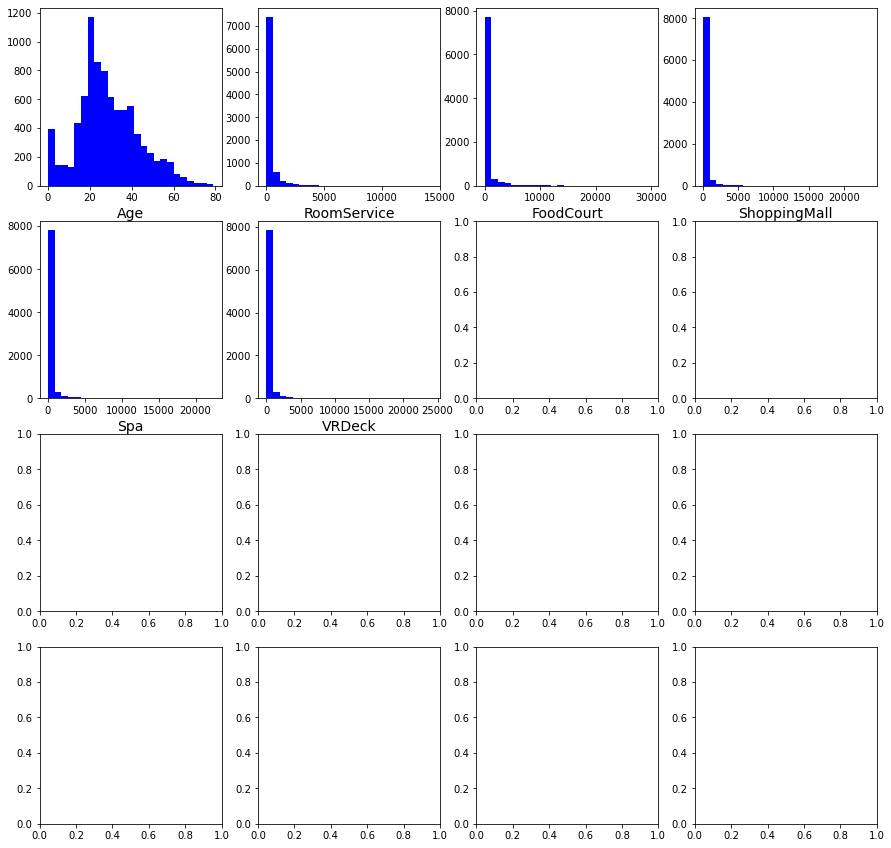

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(15, 15))

for num, feature in enumerate(numerical_features):
    data = train[feature].copy()
    axes[num//4, num%4].hist(data, bins=25, color="blue")
    axes[num//4, num%4].set_xlabel(feature, fontsize=14)


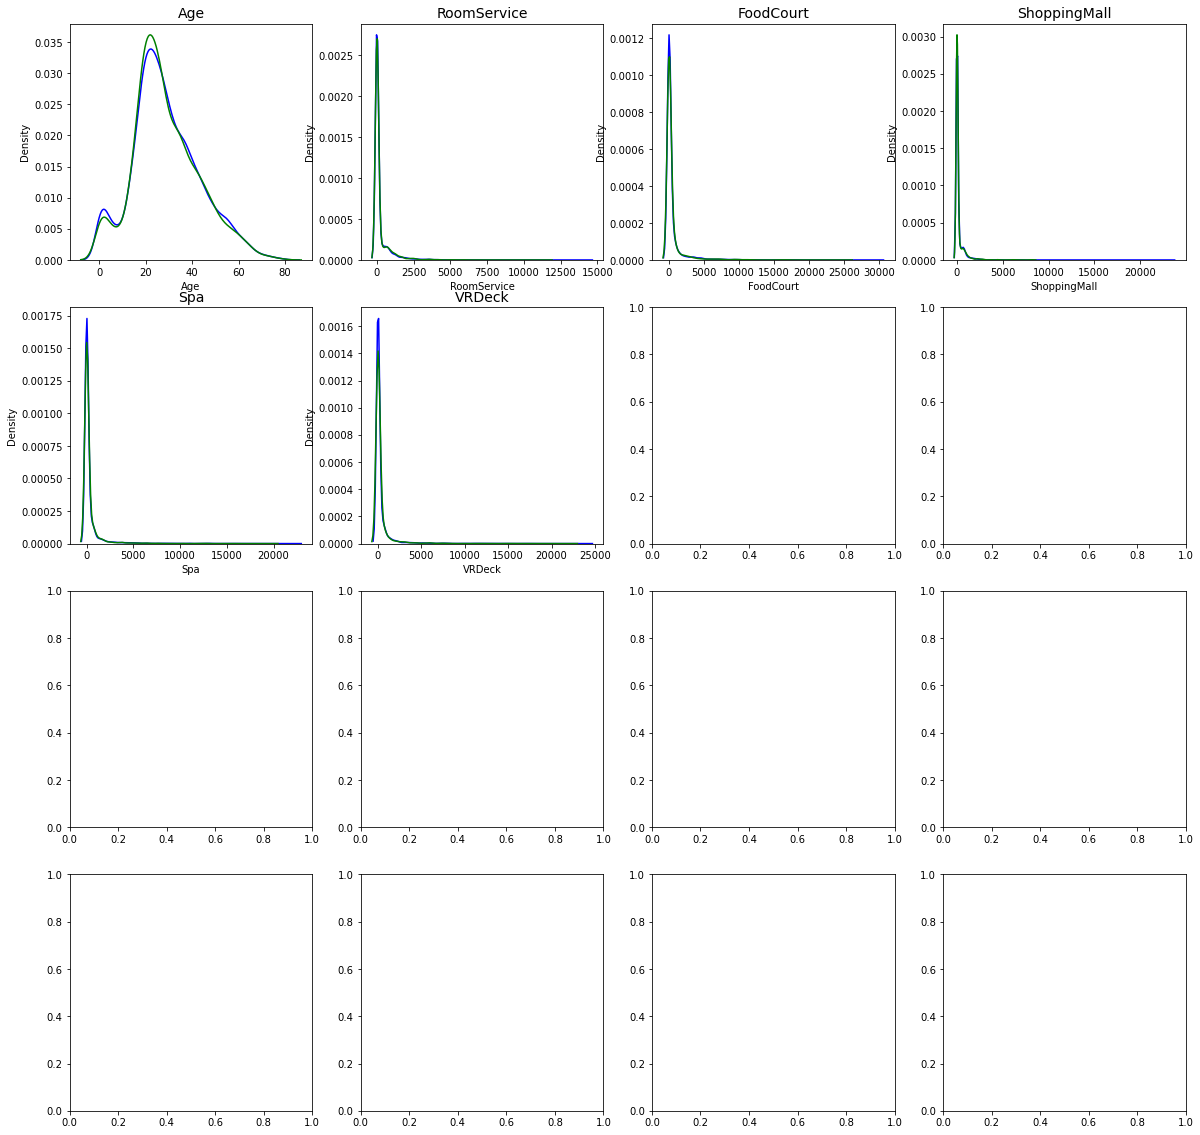

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for num, feature in enumerate(numerical_features):
    try:
        train_data, test_data = train[feature].copy(), test[feature].copy()
        sns.kdeplot(train_data, ax=axes[num//4, num%4], color="blue", label="train")
        sns.kdeplot(test_data, ax=axes[num//4, num%4], color="green", label="test")
    except RuntimeError:
        pass
    except KeyError:
        train_data = train[feature].copy()
        sns.kdeplot(train_data, ax=axes[num//4, num%4], color="blue", label="train")
    axes[num//4, num%4].set_title(feature, fontsize=14)


# **Categorical Features**

In [11]:
categorical_features = train.select_dtypes(include=[np.object])
print(f"Categorical Feature Count {categorical_features.shape[1]}")
categorical_features.head(n=2)

Categorical Feature Count 7


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: DeprecationWarning: `np.object` is a deprecated alias for the builtin `object`. To silence this warning, use `object` by itself. Doing this will not modify any behavior and is safe. 
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  """Entry point for launching an IPython kernel.


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,False,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,False,Juanna Vines


**Omission analysis**

<AxesSubplot:>

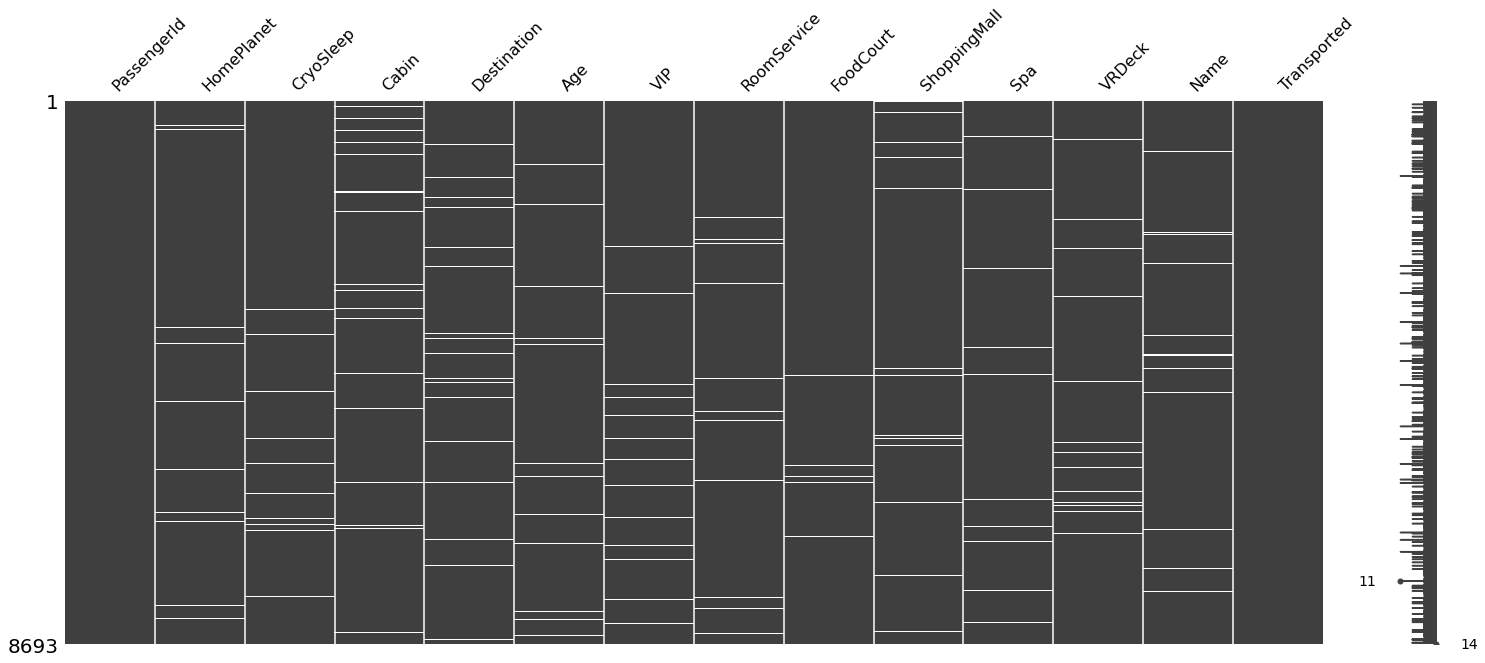

In [12]:
msno.matrix(train)

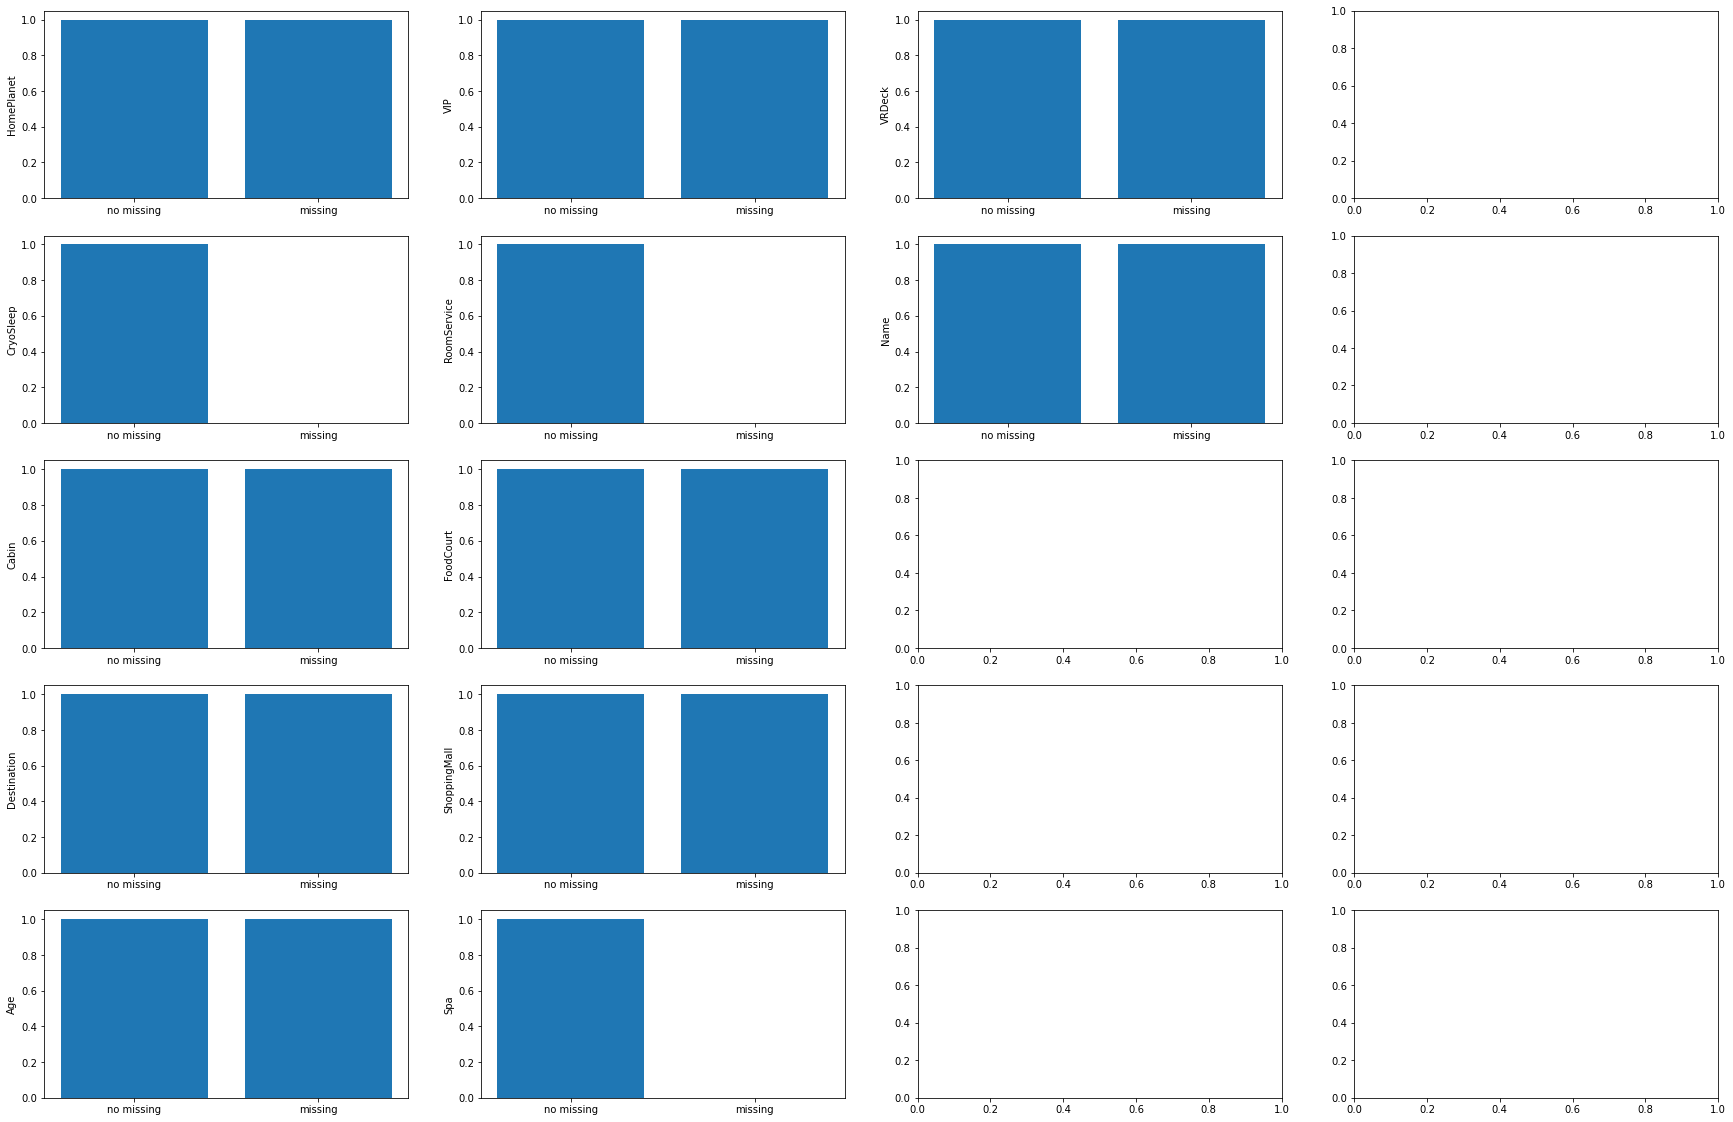

In [13]:
features_with_na = [
    feature for feature in train.columns
    if train[feature].isnull().sum() > 1]

fig, axes = plt.subplots(5, 4, figsize=(30, 20))
for num, feature in enumerate(features_with_na):
    data = train.copy()
    data[feature] = np.where(data[feature].isnull(), 1, 0)
    statistics = data.groupby(feature)["Transported"].median()
    axes[num%5, num//5].bar(statistics.index, statistics.values)
    axes[num%5, num//5].set_xticks([0, 1])
    axes[num%5, num//5].set_xticklabels(["no missing", "missing"])
    axes[num%5, num//5].set_ylabel(feature)

Text(0.5, 0, 'Missing Observations Count')

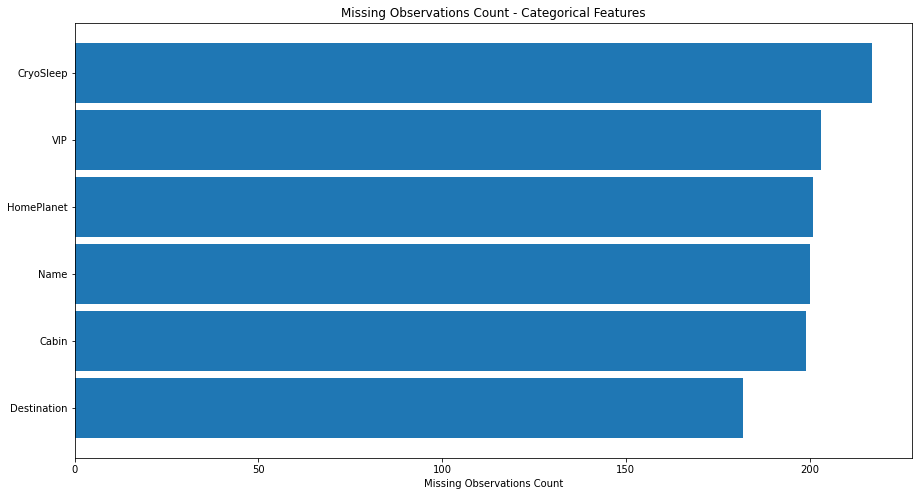

In [14]:
missing_values = categorical_features.isnull().sum(axis=0).reset_index()
missing_values.columns = ['column_name', 'missing_count']
missing_values = missing_values.loc[missing_values['missing_count']>0]
missing_values = missing_values.sort_values(by='missing_count')

ind = np.arange(missing_values.shape[0])
fig, axes = plt.subplots(figsize=(15, 8))
rects = axes.barh(ind, missing_values.missing_count.values, height=0.9)
axes.set_yticks(ind)
axes.set_yticklabels(missing_values.column_name.values, rotation='horizontal')
axes.set_title("Missing Observations Count - Categorical Features")
axes.set_xlabel("Missing Observations Count")


<AxesSubplot:>

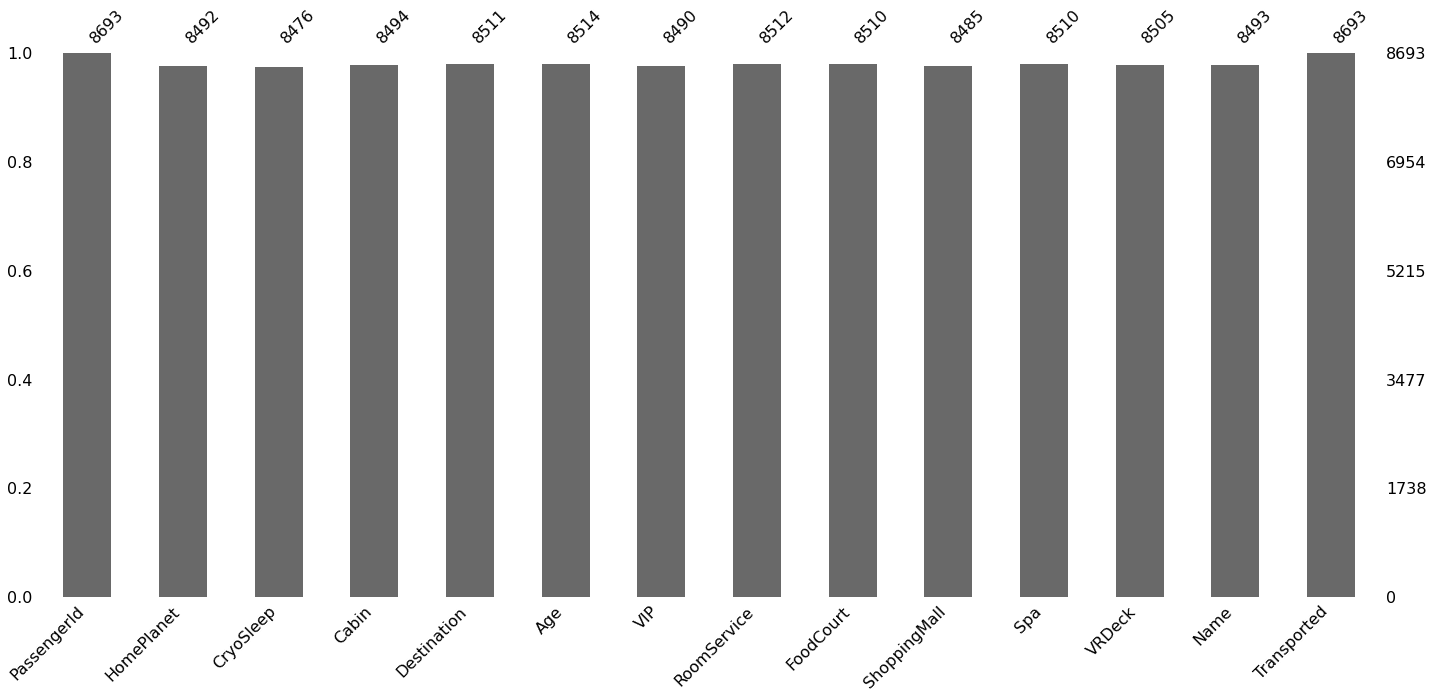

In [15]:
msno.bar(train, labels=True)

(0.0, 14.0)

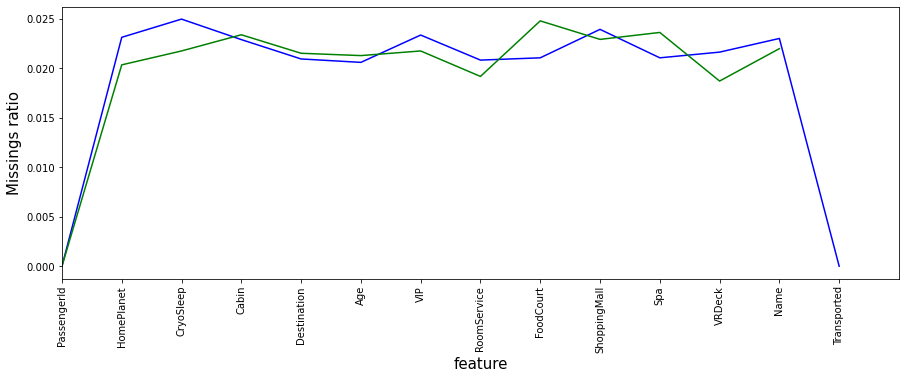

In [16]:
fig = plt.figure(figsize=(15, 5))
plt.plot(train.isnull().mean(), label="train", color="blue")
plt.plot(test.isnull().mean(), label="test", color="green")
plt.xticks(range(train.shape[1]), train.columns, rotation=90)
plt.ylabel("Missings ratio", size=15)
plt.xlabel("feature", size=15)
plt.xlim(0, train.shape[1])

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  


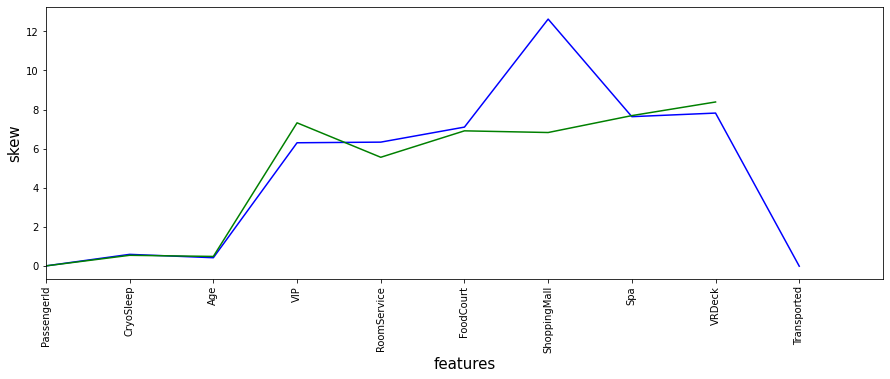

In [17]:
fig = plt.figure(figsize=(15, 5))
train_stats, test_stats = train.skew(), test.skew()
plt.plot(train_stats, color="blue", label="train")
plt.plot(test_stats, color="green", label="test")
plt.xticks(range(train_stats.shape[0]), train_stats.index, rotation=90)
plt.xlabel("features", size=15)
plt.xlim(0, len(train_stats))
plt.ylabel("skew", size=15)
plt.show()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  


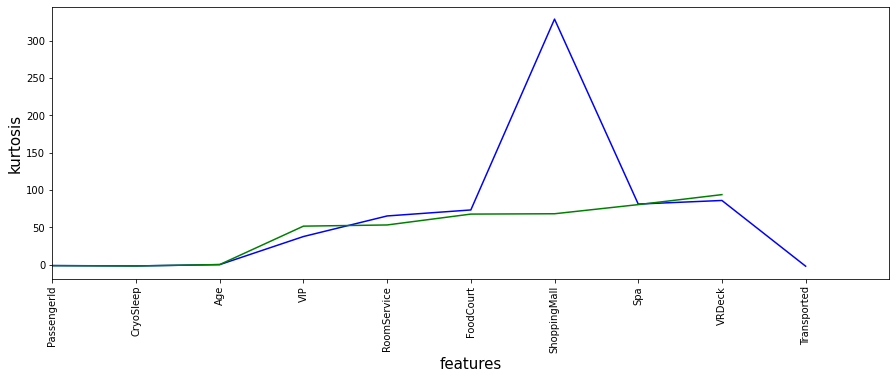

In [18]:
fig = plt.figure(figsize=(15, 5))
train_stats, test_stats = train.kurtosis(), test.kurtosis()
plt.plot(train_stats, color="blue", label="train")
plt.plot(test_stats, color="green", label="test")
plt.xticks(range(train_stats.shape[0]), train_stats.index, rotation=90)
plt.xlabel("features", size=15)
plt.ylabel("kurtosis", size=15)
plt.xlim(0, len(train_stats))
plt.show()

# **Analysis of the distribution of the target variable**

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/opt/conda/lib/python3.7/site-packages/scipy/stats/_continuous_distns.py:4322: RuntimeWarning: divide by zero encountered in log
  trm = _norm_pdf(a + b * np.log(x + np.sqrt(x2+1)))
/opt/conda/lib/python3.7/site-packages/scipy/stats/_distn_infrastructure.py:1833: RuntimeWarning: divide by zero encountered in log
  return log(self._pdf(x, *args))


<AxesSubplot:title={'center':'Log Normal'}, xlabel='Transported'>

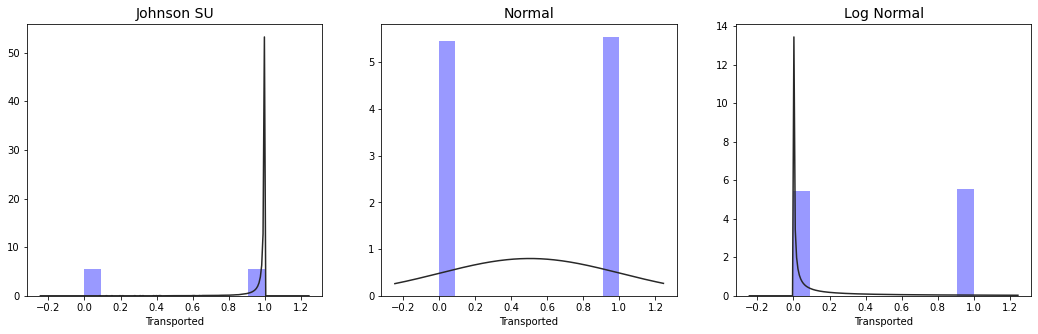

In [19]:
target = train["Transported"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].set_title("Johnson SU", fontsize=14)
sns.distplot(target, kde=False, color="blue", fit=st.johnsonsu, ax=axes[0])

axes[1].set_title("Normal", fontsize=14)
sns.distplot(target, kde=False, color="blue", fit=st.norm, ax=axes[1])

axes[2].set_title("Log Normal", fontsize=14)
sns.distplot(target, kde=False, color="blue", fit=st.lognorm, ax=axes[2])


# **Correlation Heat Map**

**A heat map is the best way to quickly get information about the strength of the relationship between variables.
At first glance, two areas of yellow color attract attention:
the first refers to the variables TotalBsmtSF and 1stFlrSF;
the second relates to GarageX variables.
Both cases show how significant the correlation between these variables is. In fact, this correlation is so strong that it may indicate a situation of multicollinearity. If we think about these variables, we can conclude that they give almost the same information, so multicollinearity is indeed the case. Heat maps are great for detecting these kinds of multicollinearity situations and are a great tool for exploration.**

In [20]:
correlation = numerical_features.corr()

<AxesSubplot:title={'center':'Correlation of Numeric Features with Transported'}>

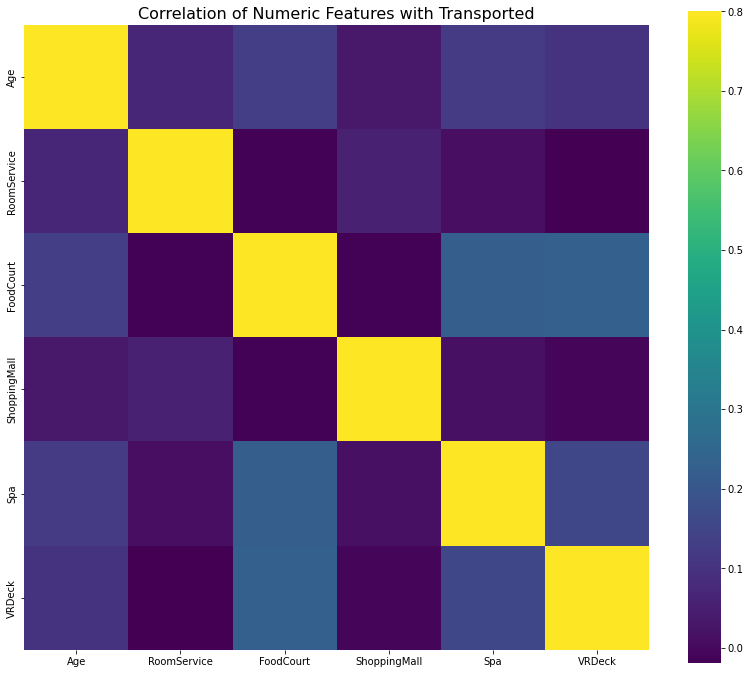

In [21]:
fig, axes = plt.subplots(figsize = (14,12))
plt.title("Correlation of Numeric Features with Transported", y=1, size=16)
sns.heatmap(correlation, square=True, vmax=0.8, cmap="viridis")

# **Nonlinear relationship between features**

**The correlation coefficient allows you to establish the linear strength of the relationship between the features, but the features can also be related non-linearly, which is difficult to determine by the correlation coefficient: there may be a situation that the features are very strongly related to each other, but the correlation coefficient is 0.
First, let's use a random forest to pick the top 10 features. They can serve as a starting point for understanding the nature of data and general understanding of data. In addition, they may provide some ideas on how to create new features. Let's start!**

In [22]:
%%time
parameters = {"max_depth": 6, "n_estimators": 25, "random_state": 27, "n_jobs": 2}

forest = RandomForestRegressor(**parameters)
forest.fit(numerical_features.fillna(-9999), target)

CPU times: user 241 ms, sys: 3.92 ms, total: 245 ms
Wall time: 219 ms


RandomForestRegressor(max_depth=6, n_estimators=25, n_jobs=2, random_state=27)

Text(0.5, 1.0, 'What are the top important features to start with?')

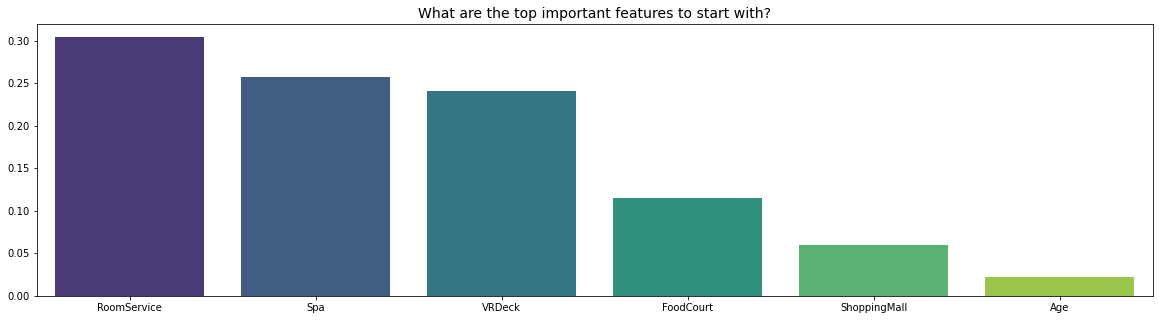

In [23]:
n_top = 10
importances = forest.feature_importances_
idx = np.argsort(importances)[::-1][0:n_top]
feature_names = numerical_features.columns

plt.figure(figsize=(20, 5))
sns.barplot(x=feature_names[idx], y=importances[idx], palette="viridis")
plt.title("What are the top important features to start with?", size=14)

# **Pair Plot**

**PairPlor between Transported and highly correlated variables. We build this graph for a better understanding of the nature of the relationship between the target variable and the feature. Using the correlation matrix, we found that there is a relationship between certain features and the target variable, but the nature of this relationship remains unclear. Building a PairPlot to better understand the nature of this relationship;**

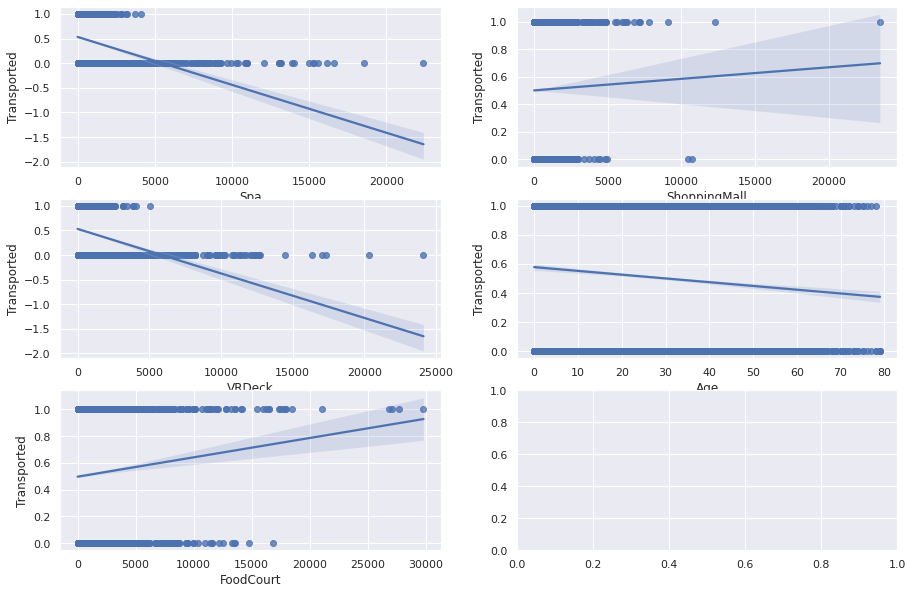

In [24]:
sns.set()
features = [
    "Spa",
    "VRDeck",
    "FoodCourt",
    "ShoppingMall",
    "Age"
]

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
for num, feature in enumerate(features):
    sns.regplot(
        x=feature,
        y="Transported",
        data=train,
        ax=axes[num%3, num//3],
        scatter=True,
        fit_reg=True
    )

# **Distribution analysis on training and test**

**The coincidence of distributions on the sample for training and for testing is one of the key concepts of statistical learning. By training the model on some data, we accept the hypothesis that the model should work on the same data.**

**Kolmogorov-Smirnov Test**

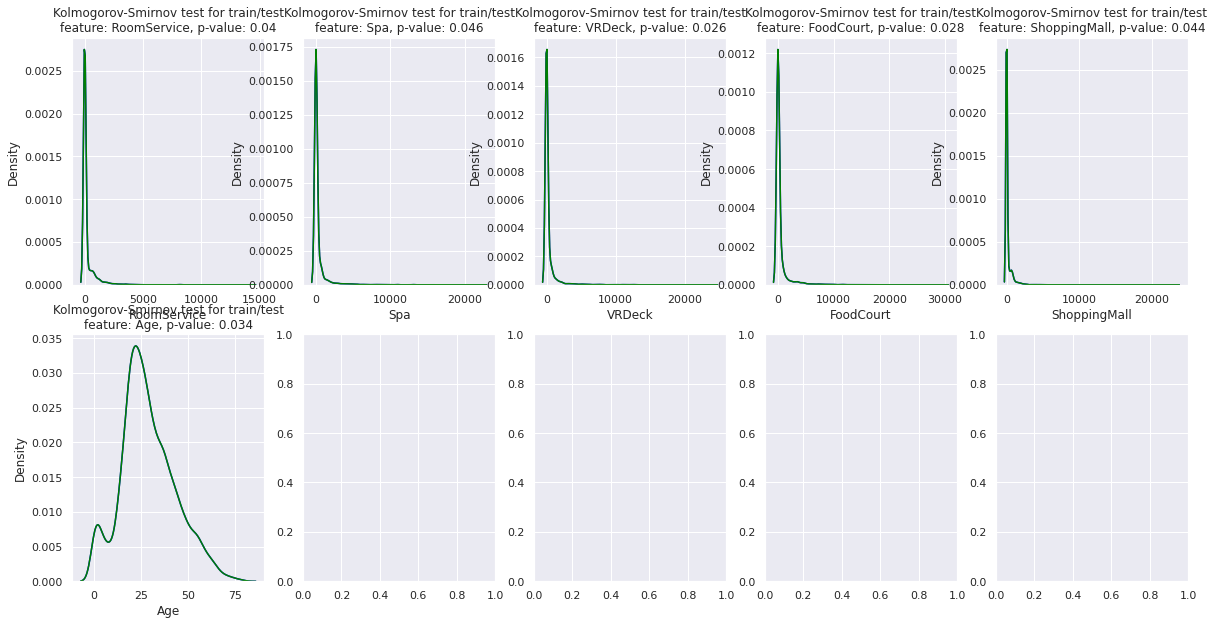

In [25]:
statistics_array = []
fig, axes = plt.subplots(2, 5, figsize=(20, 10))

for num, feature in enumerate(feature_names[idx]):
    statistic, pvalue = ks_2samp(
        train[feature].sample(500), test[feature].sample(500)
    )
    statistics_array.append(statistic)

    sns.kdeplot(train[feature], ax=axes[num//5, num%5], color="Blue", label="Train")
    sns.kdeplot(train[feature], ax=axes[num//5, num%5], color="Green", label="Test")

    axes[num//5, num%5].set_title(
        (f"Kolmogorov-Smirnov test for train/test\n"
        f"feature: {feature}, p-value: {round(statistic, 3)}")
    )